<a href="https://colab.research.google.com/github/YUFEIFUT/SparrowRecSys/blob/read_source/TFRecModel/src/com/sparrowrecsys/offline/ipynb/colab%E4%BD%9C%E4%B8%BAtf_serving%E7%9A%84%E6%B5%8B%E8%AF%95%E6%9C%8D%E5%8A%A1%E5%99%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 安装 TensorFlow Serving
此单元格将添加 TensorFlow Serving 的软件包源，并安装模型服务器。

In [1]:
# 添加 TensorFlow Serving 的 APT 软件源
!echo "deb http://storage.googleapis.com/tensorflow-serving-apt stable tensorflow-model-server tensorflow-model-server-universal" | tee /etc/apt/sources.list.d/tensorflow-serving.list && \
curl https://storage.googleapis.com/tensorflow-serving-apt/tensorflow-serving.release.pub.gpg | apt-key add -

# 更新软件列表并安装 tensorflow-model-server
!apt update
!apt-get install tensorflow-model-server

deb http://storage.googleapis.com/tensorflow-serving-apt stable tensorflow-model-server tensorflow-model-server-universal
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0Warning: apt-key is deprecated. Manage keyring files in trusted.gpg.d instead (see apt-key(8)).
100  2943  100  2943    0     0   7735      0 --:--:-- --:--:-- --:--:--  7744
OK
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http

安装完成后，您可以通过运行以下命令来确认安装的版本。

In [2]:
# 检查 TensorFlow Model Server 的版本
!tensorflow_model_server --version

TensorFlow ModelServer: 2.20.0+dev.sha.bc7e9d2
TensorFlow Library: 2.20.0-dev0+selfbuilt


### 下载测试模型数据
我们将克隆 TensorFlow Serving 的仓库以获取官方提供的测试模型（如 `half_plus_two`）。

In [3]:
# 克隆仓库（如果目录已存在则跳过）
import os
if not os.path.exists('serving'):
    !git clone https://github.com/tensorflow/serving

# 设置测试数据路径
import os
testdata_path = os.path.join(os.getcwd(), "serving/tensorflow_serving/servables/tensorflow/testdata")
model_path = os.path.join(testdata_path, "saved_model_half_plus_two_cpu")

print(f"模型路径: {model_path}")

Cloning into 'serving'...
remote: Enumerating objects: 40388, done.
remote: Counting objects: 100% (282/282), done.
remote: Compressing objects: 100% (177/177), done.
remote: Total 40388 (delta 201), reused 110 (delta 103), pack-reused 40106 (from 4)
Receiving objects: 100% (40388/40388), 20.01 MiB | 18.28 MiB/s, done.
Resolving deltas: 100% (32861/32861), done.
模型路径: /content/serving/tensorflow_serving/servables/tensorflow/testdata/saved_model_half_plus_two_cpu


### 启动 TensorFlow Serving 服务
由于 Colab 不方便运行 Docker 容器，我们直接使用已安装的 `tensorflow_model_server` 在后台启动服务。

In [4]:
# 使用 nohup 在后台启动模型服务器，监听 8501 端口
os.environ['MODEL_PATH'] = model_path

!nohup tensorflow_model_server \
    --rest_api_port=8501 \
    --model_name=half_plus_two \
    --model_base_path=$MODEL_PATH > server.log 2>&1 &

print("TensorFlow Serving 正在后台启动... 日志将写入 server.log")

TensorFlow Serving 正在后台启动... 日志将写入 server.log


### 验证服务是否成功启动
等待几秒钟后，我们可以检查日志或尝试发送一个预测请求。

In [5]:
# 检查日志最后几行，看是否加载成功
!tail server.log

# 发送一个测试请求
!curl -d '{"instances": [1.0, 2.0, 5.0]}' -X POST http://localhost:8501/v1/models/half_plus_two:predict

2026-06-24 15:49:10.109228: I external/org_tensorflow/tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 45538 microseconds.
2026-06-24 15:49:10.109363: I tensorflow_serving/servables/tensorflow/saved_model_warmup_util.cc:85] No warmup data file found at /content/serving/tensorflow_serving/servables/tensorflow/testdata/saved_model_half_plus_two_cpu/00000123/assets.extra/tf_serving_warmup_requests
2026-06-24 15:49:10.218735: I tensorflow_serving/core/loader_harness.cc:104] Successfully loaded servable version {name: half_plus_two version: 123}
I0000 00:00:1782316150.219428    3172 server_core.cc:537] Finished adding/updating models
2026-06-24 15:49:10.220825: I tensorflow_serving/model_servers/server.cc:124] Using InsecureServerCredentials
2026-06-24 15:49:10.220953: I tensorflow_serving/model_servers/server.cc:395] Profiler service is enabled
2026-06-24 15:49:10.221571: I tensorflow_serving/model_servers/server.cc:430] Running gRPC Mo

### 使用 ngrok 暴露公网访问接口
我们将安装 `pyngrok` 并通过它将本地的 8501 端口映射到公网。

In [6]:
# 安装 pyngrok
!pip install pyngrok

请在下方填入您的 ngrok Authtoken（可以从 ngrok 官网控制台获取）。

In [7]:
from pyngrok import ngrok
from google.colab import userdata
import os

try:
    # 从 Colab Secrets 中安全读取 Token
    # 请确保您已在左侧“钥匙”面板添加了名为 NGROK_TOKEN 的变量
    NGROK_TOKEN = userdata.get('NGROK_TOKEN')

    # 尝试关闭现有的 ngrok 进程以防冲突
    ngrok.kill()
    # 设置 Token
    ngrok.set_auth_token(NGROK_TOKEN)

    # 创建 HTTP 隧道指向 TensorFlow Serving 的 8501 端口
    tunnel = ngrok.connect(8501, "http")
    public_url = tunnel.public_url
    print(f"TensorFlow Serving 公网访问地址: {public_url}")
except userdata.SecretNotFoundError:
    print("❌ 错误：未在 Colab Secrets 中找到 NGROK_TOKEN。")
    print("请点击左侧钥匙图标，添加 Name 为 NGROK_TOKEN 的密钥并开启访问权限。")
except Exception as e:
    print(f"发生错误: {e}")

TensorFlow Serving 公网访问地址: https://footbath-naming-impaired.ngrok-free.dev


### 外部访问示例
现在您可以复制上面的 `public_url` 地址，在您的本地终端或其他代码中使用它。示例：

In [8]:
# 确保 public_url 已成功定义后再进行打印
if 'public_url' in locals():
    print(f"您可以尝试在您自己电脑的终端运行以下命令来测试远程访问:")
    print(f"curl -d '{{\"instances\": [1.0, 2.0, 5.0]}}' -X POST {public_url}/v1/models/half_plus_two:predict")
else:
    print("❌ 公网隧道尚未成功建立。请先在上面的单元格中填入正确的 Token 并运行成功。")

您可以尝试在您自己电脑的终端运行以下命令来测试远程访问:
curl -d '{"instances": [1.0, 2.0, 5.0]}' -X POST https://footbath-naming-impaired.ngrok-free.dev/v1/models/half_plus_two:predict


windows上调用

curl -X POST https://footbath-naming-impaired.ngrok-free.dev/v1/models/half_plus_two:predict -H "Content-Type: application/json" -d "{\"instances\": [1.0, 2.0, 5.0]}"

## 克隆仓库

In [9]:
!git clone https://github.com/YUFEIFUT/SparrowRecSys.git

Cloning into 'SparrowRecSys'...
remote: Enumerating objects: 2819, done.
remote: Counting objects: 100% (667/667), done.
remote: Compressing objects: 100% (305/305), done.
remote: Total 2819 (delta 245), reused 479 (delta 188), pack-reused 2152 (from 2)
Receiving objects: 100% (2819/2819), 175.27 MiB | 22.96 MiB/s, done.
Resolving deltas: 100% (576/576), done.


In [10]:
# 切换 SparrowRecSys 仓库到 read_source 分支
!cd /content/SparrowRecSys && git checkout read_source

Branch 'read_source' set up to track remote branch 'read_source' from 'origin'.
Switched to a new branch 'read_source'


## EmbeddingMLP.py

### 现代 Keras 实现版本 (适配 Keras 3 / TF 2.16+)
由于 `tf.feature_column` 及其相关的 `DenseFeatures` 在新版本中已不再推荐使用且存在严重的 API 路径变更问题，本单元格使用 Keras 原生的 **Preprocessing Layers** (如 `StringLookup`, `IntegerLookup`) 重新实现。这种方式将特征处理直接嵌入到模型中，无需外部特征层。

<font color='red'>这个就当作注释看吧，也不用运行了</font>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import pandas as pd
import numpy as np

# 1. 指定训练集和测试集的路径
train_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/trainingSamplesByTimeStamp.csv"
validation_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/validationSamplesByTimeStamp.csv"
test_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/testSamplesByTimeStamp.csv"

# 2. 定义特征清单与词表
# 电影风格（Genre）的全量枚举值，用于构建 StringLookup 的词表
genre_vocab = ['Film-Noir', 'Action', 'Adventure', 'Horror', 'Romance', 'War', 'Comedy', 'Western', 'Documentary',
               'Sci-Fi', 'Drama', 'Thriller', 'Crime', 'Fantasy', 'Animation', 'IMAX', 'Mystery', 'Children', 'Musical']

# 类别特征列表（包含用户偏好风格和电影自身风格）
genre_features = ['userGenre1', 'userGenre2', 'userGenre3', 'userGenre4', 'userGenre5',
                  'movieGenre1', 'movieGenre2', 'movieGenre3']
# 数值型特征列表（发行年份、评分统计信息等）
numeric_features = ['releaseYear', 'movieRatingCount', 'movieAvgRating',
                    'movieRatingStddev', 'userRatingCount', 'userAvgRating', 'userRatingStddev']

# 3. 构造输入层并进行预处理
all_inputs = {}  # 保存所有输入层
encoded_features = []  # 保存经过处理后的特征

# --- A. 处理数值特征 ---
for header in numeric_features:
    # 为每个数值特征定义一个 Input 层，接收 float32 类型数据
    # 为什么 shape=(1,)？因为一个特征只有一个数字
    numeric_col = tf.keras.Input(shape=(1,), name=header, dtype='float32')
    all_inputs[header] = numeric_col
    # 数值特征直接加入特征列表，无需额外转换
    encoded_features.append(numeric_col)

# --- B. 处理 Genre 类别特征 (String -> Embedding) ---
for header in genre_features:
    # 定义接收字符串的输入层
    categorical_col = tf.keras.Input(shape=(1,), name=header, dtype='string')
    all_inputs[header] = categorical_col
    # 使用 StringLookup 将字符串映射为整数索引：
    # - vocabulary: 使用预定义的风格词表
    # - num_oov_indices: 设为 1，用于处理词表外的未知风格
    lookup_layer = layers.StringLookup(vocabulary=genre_vocab, mask_token=None, num_oov_indices=1)
    index = lookup_layer(categorical_col)
    # 使用 Embedding 层将索引转换为 10 维稠密向量
    # input_dim 为词表大小 + OOV + 1【这里原本的代码底层逻辑是咋样的？】
    embedding = layers.Embedding(input_dim=len(genre_vocab) + 2, output_dim=10)(index)
    # 将 Embedding 输出展平（从 [batch, 1, 10] 变为 [batch, 10]）以便拼接
    encoded_features.append(layers.Flatten()(embedding))

# --- C. 处理 ID 特征 (Int -> Embedding) ---
# 电影 ID：假设范围 1001 以内
movie_id_input = tf.keras.Input(shape=(1,), name='movieId', dtype='int64')
all_inputs['movieId'] = movie_id_input
movie_embedding = layers.Embedding(input_dim=1001, output_dim=10)(movie_id_input)
encoded_features.append(layers.Flatten()(movie_embedding))

# 用户 ID：假设范围 30001 以内
user_id_input = tf.keras.Input(shape=(1,), name='userId', dtype='int64')
all_inputs['userId'] = user_id_input
user_embedding = layers.Embedding(input_dim=30001, output_dim=10)(user_id_input)
encoded_features.append(layers.Flatten()(user_embedding))

# 4. 构建 MLP 网络 (多层感知机)
# 将所有处理后的特征（数值 + Embedding）拼接成一个长向量
#【之前的代码应该是多种特征加起来吧，现在的layers.Concatenate()(encoded_features)是什么逻辑？】
all_features = layers.Concatenate()(encoded_features)
# 两个隐藏层，每层 128 个神经元，使用 ReLU 激活函数增强非线性表达能力
x = layers.Dense(128, activation="relu")(all_features)
x = layers.Dense(128, activation="relu")(x)
# 输出层使用 Sigmoid 激活函数，输出 0 到 1 之间的点击概率值
output = layers.Dense(1, activation="sigmoid")(x)

# 定义 Keras 函数式模型
new_model = tf.keras.Model(all_inputs, output)

# 5. 编译模型
new_model.compile(
    optimizer='adam',                # Adam 优化器，自动调节学习率
    loss='binary_crossentropy',      # 二分类交叉熵损失函数
    metrics=['accuracy', tf.keras.metrics.AUC(name='roc_auc', curve='ROC')])

# 6. 优化的数据加载函数
def df_to_dataset(file_path, batch_size=32):
    """将 CSV 文件加载并转换为 tf.data.Dataset 格式"""
    df = pd.read_csv(file_path)
    feature_cols = numeric_features + genre_features + ['movieId', 'userId']

    # 标签转换为 float32
    labels = df['label'].values.astype('float32')

    # 数据清洗与类型转换
    # 1. 数值特征：填充缺失值为 0，强制转为 float32
    df[numeric_features] = df[numeric_features].fillna(0).astype('float32')
    # 2. 类别特征：填充缺失值为 'None'，强制转为 string 防止 Pandas 误识别类型
    df[genre_features] = df[genre_features].fillna('None').astype(str)
    # 3. ID 特征：取模运算确保数值不会超出 Embedding 层的 input_dim 范围
    df['movieId'] = df['movieId'].fillna(0).astype('int64') % 1001
    df['userId'] = df['userId'].fillna(0).astype('int64') % 30001

    # 构建输入字典
    input_dict = {col: df[col].values for col in feature_cols}
    # 转换为 TF 数据集
    ds = tf.data.Dataset.from_tensor_slices((input_dict, labels))
    return ds.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)

# 准备训练和测试数据
train_ds = df_to_dataset(train_path)
validation_ds = df_to_dataset(validation_path)
test_ds = df_to_dataset(test_path)

# 7. 设置早停法回调 (EarlyStopping)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_roc_auc',    # 监控验证集的 AUC
    patience=5,               # 如果连续 5 个 epoch 指标没提升就停止
    mode='max',               # 目标是最大化 AUC
    restore_best_weights=True # 停止后恢复最优权重
)

# 8. 执行训练 (赋值给 history 变量以供绘图)
print("开始带有早停法的模型训练...")
history = new_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=50,                # 设置较大的上限
    callbacks=[early_stopping]
)

# 9. 最终评估
loss, accuracy, auc = new_model.evaluate(test_ds)
print(f"\n最终评估结果: Loss: {loss:.4f}, Accuracy: {accuracy:.4f}, AUC: {auc:.4f}")

开始带有早停法的模型训练...
Epoch 1/50
2779/2779 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - accuracy: 0.5734 - loss: 4.4979 - roc_auc: 0.5865 - val_accuracy: 0.4752 - val_loss: 2.6481 - val_roc_auc: 0.6071
Epoch 2/50
2779/2779 ━━━━━━━━━━━━━━━━━━━━ 45s 11ms/step - accuracy: 0.6208 - loss: 1.5611 - roc_auc: 0.6482 - val_accuracy: 0.6889 - val_loss: 1.2165 - val_roc_auc: 0.7110
Epoch 3/50
2779/2779 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - accuracy: 0.6570 - loss: 1.0127 - roc_auc: 0.6953 - val_accuracy: 0.4188 - val_loss: 2.8174 - val_roc_auc: 0.5276
Epoch 4/50
2779/2779 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - accuracy: 0.6861 - loss: 0.7620 - roc_auc: 0.7363 - val_accuracy: 0.5148 - val_loss: 1.2101 - val_roc_auc: 0.5578
Epoch 5/50
2779/2779 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - accuracy: 0.7185 - loss: 0.5751 - roc_auc: 0.7877 - val_accuracy: 0.6437 - val_loss: 0.6364 - val_roc_auc: 0.7109
Epoch 6/50
2779/2779 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - accuracy: 0.7440 - loss: 0.5118 - roc_auc: 0.8240 - val_accuracy: 

### 1. 导出模型为 SavedModel 格式
TensorFlow Serving 需要 SavedModel 格式。我们将模型保存到 `/content/models/embedding_mlp/1`（'1' 是版本号）。

In [ ]:
import os

# 定义模型保存路径，包含版本号
export_path = "/content/models/embedding_mlp/1"

# 如果目录已存在则先删除，确保干净导出
if os.path.exists(export_path):
    import shutil
    shutil.rmtree(export_path)

# 在 Keras 3 中，导出为 SavedModel (供 TF Serving 使用) 需使用 export 方法
# 这种方式会自动处理 SavedModel 的签名，不再依赖 .save() 的后缀识别
new_model.export(export_path)

print(f"模型已成功导出至: {export_path}")
# 查看导出目录结构，确认包含 fingerprint.pb 和 variables
!ls -l {export_path}

Saved artifact at '/content/models/embedding_mlp/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): Dict[['releaseYear', TensorSpec(shape=(None, 1), dtype=tf.float32, name='releaseYear')], ['movieRatingCount', TensorSpec(shape=(None, 1), dtype=tf.float32, name='movieRatingCount')], ['movieAvgRating', TensorSpec(shape=(None, 1), dtype=tf.float32, name='movieAvgRating')], ['movieRatingStddev', TensorSpec(shape=(None, 1), dtype=tf.float32, name='movieRatingStddev')], ['userRatingCount', TensorSpec(shape=(None, 1), dtype=tf.float32, name='userRatingCount')], ['userAvgRating', TensorSpec(shape=(None, 1), dtype=tf.float32, name='userAvgRating')], ['userRatingStddev', TensorSpec(shape=(None, 1), dtype=tf.float32, name='userRatingStddev')], ['userGenre1', TensorSpec(shape=(None, 1), dtype=tf.string, name='userGenre1')], ['userGenre2', TensorSpec(shape=(None, 1), dtype=tf.string, name='userGenre2')], ['userGenre3', TensorSpec(shape=(None, 1), dtype=tf.str

### 2. 部署到 TensorFlow Serving
我们需要杀掉之前运行的 `half_plus_two` 服务的进程，并启动新的服务来加载我们的 `embedding_mlp` 模型。

### 3. 验证新模型接口
等待几秒钟确保模型加载完成后，我们尝试调用 API 接口。

In [ ]:
import os
import time

print("正在重启 TensorFlow Serving...")

# 停止旧服务
!pkill -f tensorflow_model_server

# 模型路径
os.environ['MODEL_BASE_PATH'] = "/content/models/embedding_mlp"

# 启动服务
!nohup tensorflow_model_server \
    --rest_api_port=8501 \
    --model_name=sparrow_mlp \
    --model_base_path=$MODEL_BASE_PATH \
    > server_new.log 2>&1 &

# 等待启动
time.sleep(5)

# 查看日志
print("--- 最近服务器日志 ---")
!tail -n 10 server_new.log

# 输出接口
if 'public_url' in locals():
    print(
        f"\n接口地址:"
        f"{public_url}/v1/models/sparrow_mlp:predict"
    )

正在重启 TensorFlow Serving...
--- 最近服务器日志 ---
I0000 00:00:1782196258.731269   33012 server_core.cc:516] Adding/updating models.
I0000 00:00:1782196258.731316   33012 server_core.cc:645]  (Re-)adding model: sparrow_mlp
I0000 00:00:1782196259.016528   33015 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1782196259.263992   33012 server_core.cc:537] Finished adding/updating models
[warn] getaddrinfo: address family for nodename not supported
[evhttp_server.cc : 261] NET_LOG: Entering the event loop ...

接口地址:https://footbath-naming-impaired.ngrok-free.dev/v1/models/sparrow_mlp:predict


### 4. 真实数据预测测试
我们将从测试集中提取一条数据，构造符合模型输入格式的 JSON，并通过 REST API 发送给 TensorFlow Serving。

In [ ]:
import requests
import json
import pandas as pd

# 1. 加载一小部分测试数据
test_df = pd.read_csv("/content/SparrowRecSys/src/main/resources/webroot/sampledata/testSamplesByTimeStamp.csv").iloc[299:300]

# --- 新增：打印原始数据对照 ---
print("--- 待测试样本原始特征 ---")
print(test_df.iloc[0].to_string())
print("-" * 30)

# 2. 准备输入数据 (需严格匹配导出模型时的输入层名称和类型)
instance = {}
for col in numeric_features:
    instance[col] = [float(test_df[col].fillna(0).iloc[0])]
for col in genre_features:
    instance[col] = [str(test_df[col].fillna('None').iloc[0])]
instance['movieId'] = [int(test_df['movieId'].fillna(0).iloc[0]) % 1001]
instance['userId'] = [int(test_df['userId'].fillna(0).iloc[0]) % 30001]

# 3. 构造请求体
data = json.dumps({"instances": [instance]})
headers = {"content-type": "application/json"}

# 4. 发送预测请求
predict_url = f"{public_url}/v1/models/sparrow_mlp:predict"
print(f"\n正在请求接口: {predict_url}")

response = requests.post(predict_url, data=data, headers=headers)

if response.status_code == 200:
    result = response.json()
    prediction = result['predictions'][0][0]
    print(f"\n预测成功！")
    print(f"输入样本的预测点击概率 (CTR): {prediction:.4f}")
    print(f"实际标签 (Label): {test_df['label'].iloc[0]}")
else:
    print(f"\n预测失败！")
    print(f"状态码: {response.status_code}")
    print(f"错误信息: {response.text}")

--- 待测试样本原始特征 ---
movieId                         150
userId                        20280
rating                          5.0
timestamp                1343941706
label                             1
releaseYear                    1995
movieGenre1               Adventure
movieGenre2                   Drama
movieGenre3                    IMAX
movieRatingCount              10324
movieAvgRating                 3.86
movieRatingStddev              0.86
userRatedMovie1               457.0
userRatedMovie2               300.0
userRatedMovie3               527.0
userRatedMovie4               318.0
userRatedMovie5               529.0
userRatingCount                   7
userAvgReleaseYear             1993
userReleaseYearStddev          0.49
userAvgRating                   4.5
userRatingStddev               0.71
userGenre1                    Drama
userGenre2                   Action
userGenre3                 Thriller
userGenre4                  Romance
userGenre5                Adventure
----------

### 如果上边的测试有问题，可以尝试下边的代码重启一下ngrok

In [ ]:
# 1. 检查 TensorFlow Model Server 进程状态
!ps -ef | grep tensorflow_model_server | grep -v grep

# 2. 重新启动 ngrok 隧道
from pyngrok import ngrok
from google.colab import userdata

try:
    # 杀掉所有现有的 ngrok 隧道
    ngrok.kill()

    # 获取 Token 并重新设置 (确保您已在 Secrets 中设置 NGROK_TOKEN)
    NGROK_TOKEN = userdata.get('NGROK_TOKEN')
    ngrok.set_auth_token(NGROK_TOKEN)

    # 重新建立到 8501 端口的连接
    new_tunnel = ngrok.connect(8501, "http")
    public_url = new_tunnel.public_url
    print(f"新的公网访问地址: {public_url}")
    print(f"新的预测接口地址: {public_url}/v1/models/sparrow_mlp:predict")
except Exception as e:
    print(f"重启隧道失败: {e}")

root       16351       1  1 05:43 ?        00:00:00 tensorflow_model_server --rest_api_port=8501 --model_name=sparrow_mlp --model_base_path=/content/models/embedding_mlp
新的公网访问地址: https://footbath-naming-impaired.ngrok-free.dev
新的预测接口地址: https://footbath-naming-impaired.ngrok-free.dev/v1/models/sparrow_mlp:predict


### Windows CMD `curl` 调用命令示例
将以下命令复制并粘贴到您的 Windows `cmd.exe` 命令行中执行：


In [ ]:
import json

# 提取模型所需的特征值
# 数据来源: 204,2162,4.0,836418450,1,1995,Action,"","",1782,2.97,1.06,261,377,440,11,589,39,1993,1.47,3.82,1.00,Drama,Adventure,Action,Thriller,Romance

instance_data = {
    'movieId': [204],
    'userId': [2162],
    'releaseYear': [1995.0],
    'movieRatingCount': [1782.0],
    'movieAvgRating': [2.97],
    'movieRatingStddev': [1.06],
    'userRatingCount': [39.0],
    'userAvgRating': [3.82],
    'userRatingStddev': [1.00],
    'userGenre1': ['Drama'],
    'userGenre2': ['Adventure'],
    'userGenre3': ['Action'],
    'userGenre4': ['Thriller'],
    'userGenre5': ['Romance'],
    'movieGenre1': ['Action'],
    'movieGenre2': ['None'], # Original data was empty, mapped to 'None'
    'movieGenre3': ['None']  # Original data was empty, mapped to 'None'
}

# 构造 JSON payload，使用 separators=(',', ':') 避免不必要的空白，方便 CMD 处理
payload = {"instances": [instance_data]}
json_payload = json.dumps(payload, separators=(',', ':'))

# 为 Windows CMD 逃逸内部双引号
escaped_json_payload = json_payload.replace('"', '\"')

# 构建 curl 命令
# public_url 变量来自之前的 ngrok 隧道单元格
curl_command_windows = f'curl -X POST "{public_url}/v1/models/sparrow_mlp:predict" -H "Content-Type: application/json" -d "{escaped_json_payload}"'

print("```bash") # 使用 markdown 代码块方便复制
print(curl_command_windows)
print("```")

```bash
curl -X POST "https://footbath-naming-impaired.ngrok-free.dev/v1/models/sparrow_mlp:predict" -H "Content-Type: application/json" -d "{"instances":[{"movieId":[204],"userId":[2162],"releaseYear":[1995.0],"movieRatingCount":[1782.0],"movieAvgRating":[2.97],"movieRatingStddev":[1.06],"userRatingCount":[39.0],"userAvgRating":[3.82],"userRatingStddev":[1.0],"userGenre1":["Drama"],"userGenre2":["Adventure"],"userGenre3":["Action"],"userGenre4":["Thriller"],"userGenre5":["Romance"],"movieGenre1":["Action"],"movieGenre2":["None"],"movieGenre3":["None"]}]}"
```


Windows的cmd中需要的格式

curl -X POST "https://footbath-naming-impaired.ngrok-free.dev/v1/models/sparrow_mlp:predict" ^
-H "Content-Type: application/json" ^
-d "{\"instances\":[{\"movieId\":[95],\"userId\":[11722],\"releaseYear\":[1996.0],\"movieRatingCount\":[4791.0],\"movieAvgRating\":[3.10],\"movieRatingStddev\":[0.95],\"userRatingCount\":[55.0],\"userAvgRating\":[3.56],\"userRatingStddev\":[0.87],\"userGenre1\":[\"Drama\"],\"userGenre2\":[\"Thriller\"],\"userGenre3\":[\"Action\"],\"userGenre4\":[\"Adventure\"],\"userGenre5\":[\"Crime\"],\"movieGenre1\":[\"Action\"],\"movieGenre2\":[\"Adventure\"],\"movieGenre3\":[\"Thriller\"]}]}"

## WideNDeep

In [ ]:
import tensorflow as tf
print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


### 从原本项目的代码通过claude code改造过来的

In [ ]:
"""
Wide & Deep 模型 —— 适配 TensorFlow 2.20.0 (Keras 3) 的版本。

为什么要重写？
----------------
原始 WideNDeep.py 是 TF 2.3 时代的代码，大量依赖 `tf.feature_column`
(categorical_column_with_vocabulary_list / embedding_column / crossed_column /
indicator_column 等) 以及 `tf.keras.layers.DenseFeatures`。

从 TF 2.16 起，Keras 默认升级为 Keras 3，`tf.feature_column` 和
`DenseFeatures` 已经被彻底移除。所以在 TF 2.20.0 下原代码无法运行。

本文件用 Keras 预处理层(Preprocessing Layers)重新实现等价逻辑：
    - categorical_column_with_vocabulary_list + embedding_column
        -> StringLookup + Embedding
    - categorical_column_with_identity + embedding_column
        -> 直接用 Embedding (ID 本身就是整数索引)
    - crossed_column + indicator_column
        -> HashedCrossing(output_mode='one_hot')
    - numeric_column + DenseFeatures
        -> 直接把数值 Input 拼接起来

模型结构(Wide & Deep)、特征、超参数都与原版保持一致。
"""

import os
import tensorflow as tf

# ============ 样本数据路径 ============
# 改成你本地的 trainingSamples.csv / testSamples.csv 路径。
# 这里默认指向本仓库内的 sampledata 目录。
# 从本文件(.../TFRecModel/src/com/sparrowrecsys/offline/tensorflow/) 往上 6 级即仓库根目录
training_samples_file_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/trainingSamplesByTimeStamp.csv"
validation_samples_file_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/validationSamplesByTimeStamp.csv"
test_samples_file_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/testSamplesByTimeStamp.csv"


# ============ 只选用模型真正用到的列 ============
# 关键修复(Keras 3 / TF 2.20)：
# CSV 一共有 26 列，但本模型只定义了 18 个 Input。Keras 3 的函数式模型在
# 传入的 dict 结构与 Input 结构不一致时，会从“按列名映射”退化成“按顺序映射”，
# 于是 float 列(如 rating)被错误地喂进了 string 类型的 genre Input，
# 报错 "Cast float to string is not supported"。
# 通过 select_columns 把 dataset 限制为模型用到的列(+label)，
# 使 dict 的 key 与模型 Input 名一一对应，按名字正确映射。
SELECTED_COLUMNS = [
    'movieId', 'userId', 'releaseYear',
    'movieGenre1', 'movieGenre2', 'movieGenre3',
    'movieRatingCount', 'movieAvgRating', 'movieRatingStddev',
    'userRatedMovie1',
    'userRatingCount', 'userAvgRating', 'userRatingStddev',
    'userGenre1', 'userGenre2', 'userGenre3', 'userGenre4', 'userGenre5',
    'label',
]


# 每个特征对应的 dtype（与下面模型 Input 的 dtype 严格一致）
INT_FEATURES = ['movieRatingCount', 'userRatingCount', 'releaseYear',
                'movieId', 'userId', 'userRatedMovie1']
FLOAT_FEATURES = ['movieAvgRating', 'movieRatingStddev',
                  'userAvgRating', 'userRatingStddev']
STRING_FEATURES = ['userGenre1', 'userGenre2', 'userGenre3', 'userGenre4', 'userGenre5',
                   'movieGenre1', 'movieGenre2', 'movieGenre3']


def _reorder_and_cast(features, label):
    """关键修复(Keras 3 / TF 2.20)：
    make_csv_dataset 返回的是 OrderedDict，且列顺序跟随 CSV header，
    与模型 Input 的定义顺序不同。Keras 3 在结构(OrderedDict vs dict、
    顺序不一致)不匹配时，会从“按列名映射”退化成“按位置映射”，
    导致 string 的 genre 列被喂进 int 的 ID Input，报
    'Cast string to int32 / float to string is not supported'。

    这里显式重建一个普通 dict，key 与模型 Input 一一对应，
    并把每列 cast 到模型期望的 dtype，彻底消除顺序/类型歧义。
    """
    out = {}
    # 同时把每列从 (batch,) expand 成 (batch, 1)，与 Input(shape=(1,)) 对齐
    for name in INT_FEATURES:
        out[name] = tf.expand_dims(tf.cast(features[name], tf.int32), axis=-1)
    for name in FLOAT_FEATURES:
        out[name] = tf.expand_dims(tf.cast(features[name], tf.float32), axis=-1)
    for name in STRING_FEATURES:
        col = features[name]
        if col.dtype != tf.string:
            col = tf.strings.as_string(col)
        out[name] = tf.expand_dims(col, axis=-1)
    return out, label


# ============ 加载样本为 tf.data.Dataset ============
def get_dataset(file_path):
    dataset = tf.data.experimental.make_csv_dataset(
        file_path,
        batch_size=12,
        label_name='label',
        select_columns=SELECTED_COLUMNS,
        na_value="0",
        num_epochs=1,
        ignore_errors=True)
    # 重排列顺序 + 统一 dtype，保证与模型 Input 按名字正确映射
    dataset = dataset.map(_reorder_and_cast)
    return dataset


train_dataset = get_dataset(training_samples_file_path)
validation_dataset = get_dataset(validation_samples_file_path)
test_dataset = get_dataset(test_samples_file_path)

# ============ genre(电影类型)词表 ============
genre_vocab = ['Film-Noir', 'Action', 'Adventure', 'Horror', 'Romance', 'War', 'Comedy', 'Western', 'Documentary',
               'Sci-Fi', 'Drama', 'Thriller',
               'Crime', 'Fantasy', 'Animation', 'IMAX', 'Mystery', 'Children', 'Musical']

GENRE_FEATURES = {
    'userGenre1': genre_vocab,
    'userGenre2': genre_vocab,
    'userGenre3': genre_vocab,
    'userGenre4': genre_vocab,
    'userGenre5': genre_vocab,
    'movieGenre1': genre_vocab,
    'movieGenre2': genre_vocab,
    'movieGenre3': genre_vocab
}

# ============ 定义 Keras 模型的输入层 ============
# 在 Keras 3 中，预处理层直接接收 Input 张量。
# 这里 shape=(1,) 表示每个样本一个标量(make_csv_dataset 给出的每列形状是 (batch,)，
# Keras 会自动对齐到 (batch, 1))。
inputs = {
    'movieAvgRating': tf.keras.layers.Input(name='movieAvgRating', shape=(1,), dtype='float32'),
    'movieRatingStddev': tf.keras.layers.Input(name='movieRatingStddev', shape=(1,), dtype='float32'),
    'movieRatingCount': tf.keras.layers.Input(name='movieRatingCount', shape=(1,), dtype='int32'),
    'userAvgRating': tf.keras.layers.Input(name='userAvgRating', shape=(1,), dtype='float32'),
    'userRatingStddev': tf.keras.layers.Input(name='userRatingStddev', shape=(1,), dtype='float32'),
    'userRatingCount': tf.keras.layers.Input(name='userRatingCount', shape=(1,), dtype='int32'),
    'releaseYear': tf.keras.layers.Input(name='releaseYear', shape=(1,), dtype='int32'),

    'movieId': tf.keras.layers.Input(name='movieId', shape=(1,), dtype='int32'),
    'userId': tf.keras.layers.Input(name='userId', shape=(1,), dtype='int32'),
    'userRatedMovie1': tf.keras.layers.Input(name='userRatedMovie1', shape=(1,), dtype='int32'),

    'userGenre1': tf.keras.layers.Input(name='userGenre1', shape=(1,), dtype='string'),
    'userGenre2': tf.keras.layers.Input(name='userGenre2', shape=(1,), dtype='string'),
    'userGenre3': tf.keras.layers.Input(name='userGenre3', shape=(1,), dtype='string'),
    'userGenre4': tf.keras.layers.Input(name='userGenre4', shape=(1,), dtype='string'),
    'userGenre5': tf.keras.layers.Input(name='userGenre5', shape=(1,), dtype='string'),
    'movieGenre1': tf.keras.layers.Input(name='movieGenre1', shape=(1,), dtype='string'),
    'movieGenre2': tf.keras.layers.Input(name='movieGenre2', shape=(1,), dtype='string'),
    'movieGenre3': tf.keras.layers.Input(name='movieGenre3', shape=(1,), dtype='string'),
}

# ============ Deep 部分的特征构造 ============
# 用一个列表收集所有 deep 侧的特征张量，最后 Concatenate 在一起。
deep_feature_tensors = []

# ---------- 数值特征 ----------
# 原来用 numeric_column；现在直接把数值 Input 转成 float32 后拼接。
numerical_feature_names = ['releaseYear', 'movieRatingCount', 'movieAvgRating', 'movieRatingStddev',
                           'userRatingCount', 'userAvgRating', 'userRatingStddev']
for feature_name in numerical_feature_names:
    # int 类型的数值列(如 releaseYear)统一 cast 成 float32，保证拼接时类型一致
    num_tensor = tf.keras.layers.Lambda(
        lambda x: tf.cast(x, tf.float32), name='cast_' + feature_name
    )(inputs[feature_name])
    deep_feature_tensors.append(num_tensor)

# ---------- genre 类别特征(字符串 -> 索引 -> 嵌入) ----------
# 等价于原来的 categorical_column_with_vocabulary_list + embedding_column(dim=10)
for feature_name, vocab in GENRE_FEATURES.items():
    # StringLookup 默认带 1 个 OOV(词表外) 索引，所以 input_dim = len(vocab) + 1
    lookup = tf.keras.layers.StringLookup(
        vocabulary=vocab, num_oov_indices=1, name='lookup_' + feature_name
    )(inputs[feature_name])
    emb = tf.keras.layers.Embedding(
        input_dim=len(vocab) + 1, output_dim=10, name='emb_' + feature_name
    )(lookup)
    # Embedding 输出 (batch, 1, 10)，展平成 (batch, 10)
    emb = tf.keras.layers.Flatten(name='flat_' + feature_name)(emb)
    deep_feature_tensors.append(emb)

# ---------- movieId 嵌入 ----------
# 等价于 categorical_column_with_identity(num_buckets=1001) + embedding_column(dim=10)
movie_emb = tf.keras.layers.Embedding(input_dim=1001, output_dim=10, name='emb_movieId')(inputs['movieId'])
movie_emb = tf.keras.layers.Flatten(name='flat_movieId')(movie_emb)
deep_feature_tensors.append(movie_emb)

# ---------- userId 嵌入 ----------
# 等价于 categorical_column_with_identity(num_buckets=30001) + embedding_column(dim=10)
user_emb = tf.keras.layers.Embedding(input_dim=30001, output_dim=10, name='emb_userId')(inputs['userId'])
user_emb = tf.keras.layers.Flatten(name='flat_userId')(user_emb)
deep_feature_tensors.append(user_emb)

# ============ Wide & Deep 模型架构 ============

# ---------- Deep 部分(深度学习部分) ----------
# 把所有数值特征 + 类别嵌入特征拼接成一个稠密向量，再过两层全连接。
deep = tf.keras.layers.concatenate(deep_feature_tensors, name='deep_concat')
deep = tf.keras.layers.Dense(128, activation='relu')(deep)
deep = tf.keras.layers.Dense(128, activation='relu')(deep)

# ---------- Wide 部分(线性/记忆部分) ----------
# 原来用 crossed_column([movieId, userRatedMovie1], 10000) + indicator_column。
# 现在用 HashedCrossing：把两个 ID 特征哈希交叉到 10000 个桶，输出 one-hot 向量。
# 含义和课程文章里 Google Wide&Deep 的 (已安装应用 x 曝光应用) 一致：
# movieId 是当前用户正在看并评分的电影，userRatedMovie1 是用户最近看过且喜欢的电影，
# 交叉后构成 "如果 A 则 B" 这样的简单共现规则，让模型具备记忆能力。
wide = tf.keras.layers.HashedCrossing(
    num_bins=10000, output_mode='one_hot', name='crossed_movie_ratedmovie'
)((inputs['movieId'], inputs['userRatedMovie1']))
# HashedCrossing one_hot 输出可能是 (batch, 1, 10000)，展平成 (batch, 10000)
wide = tf.keras.layers.Flatten(name='flat_wide')(wide)

# ---------- 拼接 Wide 与 Deep ----------
# Deep 提供泛化能力，Wide 提供记忆能力。
both = tf.keras.layers.concatenate([deep, wide], name='wide_and_deep_concat')
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')(both)
model = tf.keras.Model(inputs, output_layer)

# ============ 编译模型 ============
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    # 给两个 AUC 显式命名，否则 Keras 会自动命名为 auc / auc_1，
    # 早停回调要监控的 val_auc_roc 名字才稳定可控。
    metrics=['accuracy',
             tf.keras.metrics.AUC(curve='ROC', name='auc_roc'),
             tf.keras.metrics.AUC(curve='PR', name='auc_pr')])

# ============ 早停法(Early Stopping) ============
# 监控验证集的 ROC AUC：当它连续 patience 个 epoch 不再提升时停止训练，
# 并用 restore_best_weights 回滚到验证表现最好的那一轮权重，避免过拟合。
# mode='max' 因为 AUC 越大越好。
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc_roc',
    mode='max',
    patience=3,
    restore_best_weights=True)

# ============ 训练 ============
# epochs 放大到 50，实际训练轮数由早停根据验证集表现自动决定。
history = model.fit(train_dataset,
          validation_data=validation_dataset,
          epochs=50,
          callbacks=[early_stopping])

# ============ 评估 ============
test_loss, test_accuracy, test_roc_auc, test_pr_auc = model.evaluate(test_dataset)
print('\n\nTest Loss {}, Test Accuracy {}, Test ROC AUC {}, Test PR AUC {}'.format(test_loss, test_accuracy,
                                                                                   test_roc_auc, test_pr_auc))

# ============ 打印部分预测结果 ============
predictions = model.predict(test_dataset)
for prediction, goodRating in zip(predictions[:12], list(test_dataset)[0][1][:12]):
    print("Predicted good rating: {:.2%}".format(prediction[0]),
          " | Actual rating label: ",
          ("Good Rating" if bool(goodRating) else "Bad Rating"))


Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


Epoch 1/50
   7406/Unknown 95s 11ms/step - accuracy: 0.5851 - auc_pr: 0.5848 - auc_roc: 0.6051 - loss: 0.8724

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


7410/7410 ━━━━━━━━━━━━━━━━━━━━ 105s 13ms/step - accuracy: 0.6258 - auc_pr: 0.6554 - auc_roc: 0.6569 - loss: 0.6934 - val_accuracy: 0.7060 - val_auc_pr: 0.7929 - val_auc_roc: 0.7210 - val_loss: 0.5940
Epoch 2/50
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 92s 12ms/step - accuracy: 0.6976 - auc_pr: 0.7568 - auc_roc: 0.7577 - loss: 0.5852 - val_accuracy: 0.7044 - val_auc_pr: 0.7829 - val_auc_roc: 0.7043 - val_loss: 0.5965
Epoch 3/50
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 91s 12ms/step - accuracy: 0.7355 - auc_pr: 0.8040 - auc_roc: 0.8056 - loss: 0.5351 - val_accuracy: 0.7166 - val_auc_pr: 0.8175 - val_auc_roc: 0.7515 - val_loss: 0.5782
Epoch 4/50
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 137s 18ms/step - accuracy: 0.7557 - auc_pr: 0.8269 - auc_roc: 0.8276 - loss: 0.5091 - val_accuracy: 0.7151 - val_auc_pr: 0.8097 - val_auc_roc: 0.7421 - val_loss: 0.5715
Epoch 5/50
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 92s 12ms/step - accuracy: 0.7677 - auc_pr: 0.8409 - auc_roc: 0.8413 - loss: 0.4908 - val_accuracy: 0.7141 - val_auc_pr: 0.8190 

### 画图

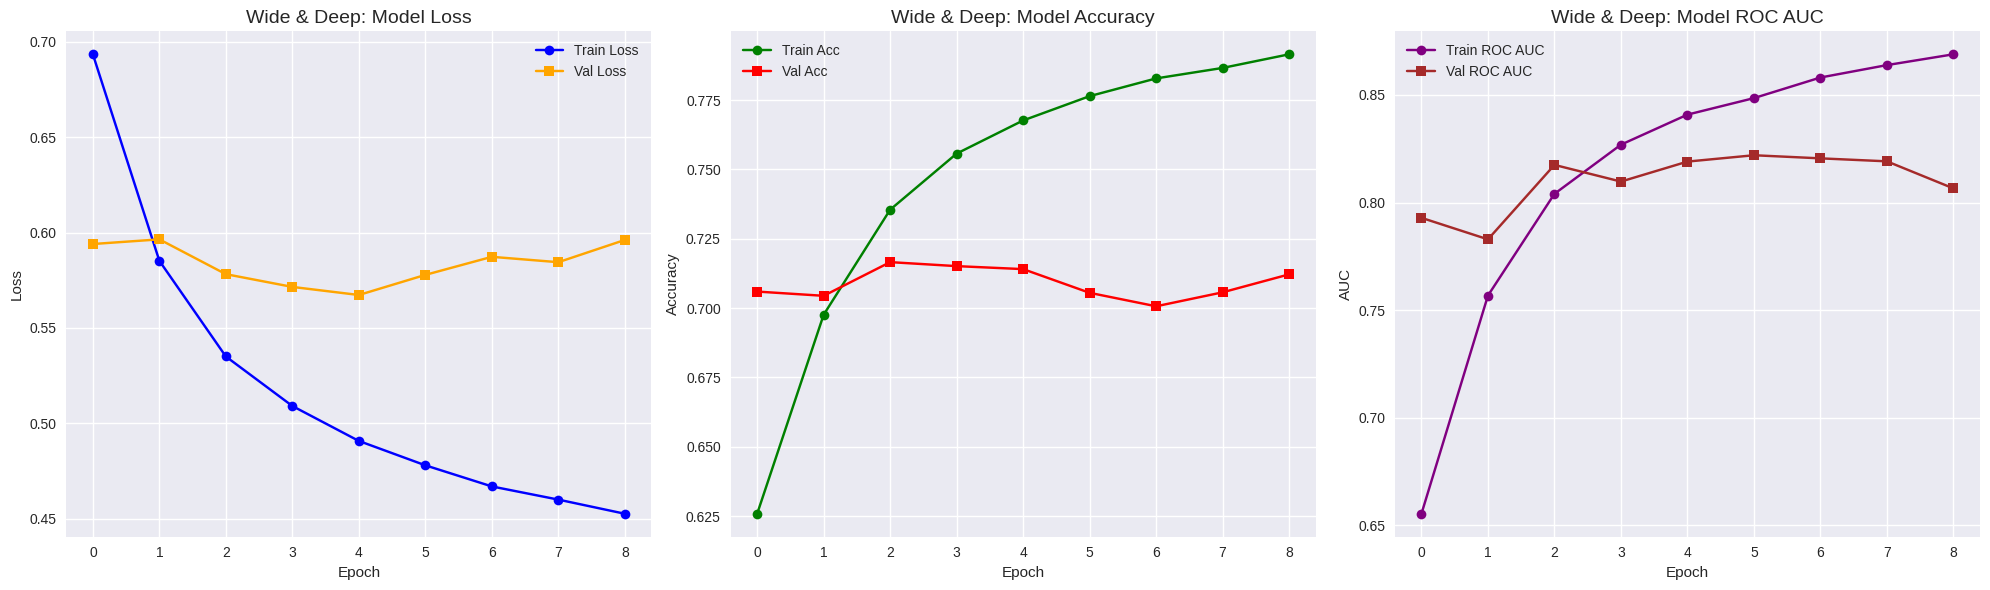

In [ ]:
import matplotlib.pyplot as plt

# 设置绘图风格
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. 绘制 Loss 曲线
axes[0].plot(history.history['loss'], label='Train Loss', marker='o', color='b')
if 'val_loss' in history.history:
    axes[0].plot(history.history['val_loss'], label='Val Loss', marker='s', color='orange')
axes[0].set_title('Wide & Deep: Model Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# 2. 绘制 Accuracy 曲线
axes[1].plot(history.history['accuracy'], label='Train Acc', marker='o', color='g')
if 'val_accuracy' in history.history:
    axes[1].plot(history.history['val_accuracy'], label='Val Acc', marker='s', color='red')
axes[1].set_title('Wide & Deep: Model Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# 3. 绘制 ROC AUC 曲线 (根据训练日志，指标名包含具体的后缀，如 auc_6)
# 自动检测包含 'auc' 的 key
auc_key = [k for k in history.history.keys() if 'auc' in k and 'val' not in k][0]
val_auc_key = 'val_' + auc_key if 'val_' + auc_key in history.history else None

axes[2].plot(history.history[auc_key], label='Train ROC AUC', marker='o', color='purple')
if val_auc_key:
    axes[2].plot(history.history[val_auc_key], label='Val ROC AUC', marker='s', color='brown')
axes[2].set_title('Wide & Deep: Model ROC AUC', fontsize=14)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()

plt.tight_layout()
plt.show()

### 1. 导出 Wide & Deep 模型
我们将模型导出到 `/content/models/wide_deep/1`。

In [ ]:
import os
import shutil

# 定义路径
wd_export_path = "/content/models/wide_deep/1"

# 清理旧导出
if os.path.exists(wd_export_path):
    shutil.rmtree(wd_export_path)

# 导出模型
model.export(wd_export_path)
print(f"Wide & Deep 模型已导出至: {wd_export_path}")

Saved artifact at '/content/models/wide_deep/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): Dict[['movieAvgRating', TensorSpec(shape=(None, 1), dtype=tf.float32, name='movieAvgRating')], ['movieRatingStddev', TensorSpec(shape=(None, 1), dtype=tf.float32, name='movieRatingStddev')], ['movieRatingCount', TensorSpec(shape=(None, 1), dtype=tf.int32, name='movieRatingCount')], ['userAvgRating', TensorSpec(shape=(None, 1), dtype=tf.float32, name='userAvgRating')], ['userRatingStddev', TensorSpec(shape=(None, 1), dtype=tf.float32, name='userRatingStddev')], ['userRatingCount', TensorSpec(shape=(None, 1), dtype=tf.int32, name='userRatingCount')], ['releaseYear', TensorSpec(shape=(None, 1), dtype=tf.int32, name='releaseYear')], ['movieId', TensorSpec(shape=(None, 1), dtype=tf.int32, name='movieId')], ['userId', TensorSpec(shape=(None, 1), dtype=tf.int32, name='userId')], ['userRatedMovie1', TensorSpec(shape=(None, 1), dtype=tf.int32, name='userRatedMo

### 2. 重启 TF Serving 加载 Wide & Deep 模型

In [ ]:
import time

print("正在停止旧服务并启动 Wide & Deep 服务...")
!pkill -f tensorflow_model_server

os.environ['WD_MODEL_BASE_PATH'] = "/content/models/wide_deep"

# 启动服务，命名为 sparrow_wd
!nohup tensorflow_model_server \
    --rest_api_port=8501 \
    --model_name=sparrow_wd \
    --model_base_path=$WD_MODEL_BASE_PATH \
    > server_wd.log 2>&1 &

# 等待启动并检查日志
time.sleep(5)
!tail -n 5 server_wd.log

正在停止旧服务并启动 Wide & Deep 服务...
I0000 00:00:1782288927.359110    9335 server_core.cc:645]  (Re-)adding model: sparrow_wd
I0000 00:00:1782288927.648638    9338 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1782288927.899405    9335 server_core.cc:537] Finished adding/updating models
[warn] getaddrinfo: address family for nodename not supported
[evhttp_server.cc : 261] NET_LOG: Entering the event loop ...


### 3. 从测试文件中读取一条数据并进行预测
我们将直接从 `testSamplesByTimeStamp.csv` 读取一行数据进行验证。

In [ ]:
import requests
import json
import pandas as pd

# 1. 从测试文件读取一条数据 (例如第 500 行)
sample_df = pd.read_csv(test_samples_file_path).iloc[0:1]

print("--- 选取的测试样本原始特征 ---")
display(sample_df)

# 2. 构造输入数据 (需与 Wide & Deep 的输入层严格对应)
# 注意：Wide & Deep 的训练代码中包含 movieId 和 userRatedMovie1 的交叉
instance = {}

# 处理整数特征
for col in INT_FEATURES:
    instance[col] = [int(sample_df[col].fillna(0).iloc[0])]

# 处理浮点特征
for col in FLOAT_FEATURES:
    instance[col] = [float(sample_df[col].fillna(0).iloc[0])]

# 处理字符串特征
for col in STRING_FEATURES:
    instance[col] = [str(sample_df[col].fillna('None').iloc[0])]

# 3. 发送请求
predict_url = f"{public_url}/v1/models/sparrow_wd:predict"
payload = json.dumps({"instances": [instance]})
headers = {"content-type": "application/json"}

response = requests.post(predict_url, data=payload, headers=headers)

if response.status_code == 200:
    res_json = response.json()
    score = res_json['predictions'][0][0]
    print(f"\n预测点击概率 (CTR): {score:.4%}")
    print(f"实际标签 (Label): {sample_df['label'].iloc[0]}")
else:
    print(f"预测失败: {response.status_code}")
    print(response.text)

--- 选取的测试样本原始特征 ---


,movieId,userId,rating,timestamp,label,releaseYear,movieGenre1,movieGenre2,movieGenre3,movieRatingCount,...,userRatingCount,userAvgReleaseYear,userReleaseYearStddev,userAvgRating,userRatingStddev,userGenre1,userGenre2,userGenre3,userGenre4,userGenre5
0,223,9077,2.5,1247908275,0,1994,Comedy,NaN,NaN,5102,...,10,1982,15.33,3.85,0.53,Thriller,Action,Sci-Fi,Drama,Horror



预测点击概率 (CTR): 82.2570%
实际标签 (Label): 0


### 生成适用于 Windows CMD 的 Wide & Deep 模型调用命令
运行以下单元格即可获得可以直接复制到 CMD 的 `curl` 命令。

In [ ]:
import json

# 1. 构造输入数据
instance_data = {}
for col in INT_FEATURES:
    instance_data[col] = [int(sample_df[col].fillna(0).iloc[0])]
for col in FLOAT_FEATURES:
    instance_data[col] = [float(sample_df[col].fillna(0).iloc[0])]
for col in STRING_FEATURES:
    instance_data[col] = [str(sample_df[col].fillna('None').iloc[0])]

# 2. 构造 Payload
payload = {"instances": [instance_data]}
json_payload = json.dumps(payload, separators=(',', ':'))

# 3. 关键修复：为 Windows CMD 正确转义双引号 (将 " 替换为 \")
escaped_json = json_payload.replace('"', '\\\"')

# 4. 构建最终命令
cmd_command = f'curl -X POST "{public_url}/v1/models/sparrow_wd:predict" -H "Content-Type: application/json" -d "{escaped_json}"'

print("请复制以下修正后的命令到 Windows CMD 执行:\n")
print(cmd_command)

请复制以下修正后的命令到 Windows CMD 执行:

curl -X POST "https://footbath-naming-impaired.ngrok-free.dev/v1/models/sparrow_wd:predict" -H "Content-Type: application/json" -d "{\"instances\":[{\"movieRatingCount\":[13826],\"userRatingCount\":[16],\"releaseYear\":[1994],\"movieId\":[318],\"userId\":[9077],\"userRatedMovie1\":[19],\"movieAvgRating\":[4.45],\"movieRatingStddev\":[0.72],\"userAvgRating\":[3.56],\"userRatingStddev\":[0.63],\"userGenre1\":[\"Thriller\"],\"userGenre2\":[\"Drama\"],\"userGenre3\":[\"Comedy\"],\"userGenre4\":[\"Action\"],\"userGenre5\":[\"Sci-Fi\"],\"movieGenre1\":[\"Crime\"],\"movieGenre2\":[\"Drama\"],\"movieGenre3\":[\"None\"]}]}"


## NeuralCF

### 模型代码

In [15]:
"""
NeuralCF — TensorFlow 3.x 适配版（改进版）
==========================================
原代码基于 TF 2.3，使用 tf.feature_column + DenseFeatures（TF 3.x 已移除）。
本版本改用手动 Embedding 层 + Functional API，保留原始模型结构不变。

改进点（针对训练指标持续下降问题）：
1. batch_size 12 → 256（减少梯度噪声，稳定训练）
2. Embedding 加 L2 正则化（防止 Embedding 向量过拟合噪声）
3. MLP 层间加 Dropout（防止交互层过拟合）
4. 加入 ReduceLROnPlateau 学习率调度（收敛后自动降低学习率）
5. 保留早停法 + 验证集

适配要点：
1. tf.feature_column → tf.keras.layers.Embedding（手动构建嵌入层）
2. DenseFeatures 移除，直接使用 Embedding 层输出
3. 新增验证集 + 早停法（monitor='val_roc_auc', patience=5, mode='max', restore_best_weights=True）
4. 数据路径改为 Google Colab 路径
5. CSV 共 26 列，但模型只使用 movieId 和 userId，用 select_columns 过滤
"""

import tensorflow as tf

# ============================================================
# 数据路径（Google Colab）
# ============================================================
train_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/trainingSamplesByTimeStamp.csv"
validation_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/validationSamplesByTimeStamp.csv"
test_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/testSamplesByTimeStamp.csv"

# ============================================================
# 超参数
# ============================================================
BATCH_SIZE = 12        # 增大 batch_size，减少梯度噪声（原代码 12）
EMBEDDING_DIM = 10      # Embedding 维度（与原代码一致）
MOVIE_BUCKETS = 1001    # movieId 的 bucket 数（与原代码一致）
USER_BUCKETS = 30001    # userId 的 bucket 数（与原代码一致）
EPOCHS = 100            # 最大训练轮数（早停法会提前终止）
L2_REG = 1e-5           # Embedding L2 正则化系数
DROPOUT_RATE = 0.2      # Dropout 比率


# ============================================================
# 数据加载
# ============================================================
def get_dataset(file_path, batch_size=BATCH_SIZE):
    """
    使用 make_csv_dataset 加载 CSV 文件为 tf.data.Dataset。
    make_csv_dataset 会自动将 CSV 列解析为字典格式 (feature_name -> tensor)，
    并将 label_name 指定的列作为标签返回。

    适配变更：
    - CSV 共 26 列，但模型只使用 movieId 和 userId 两列
    - make_csv_dataset 默认返回所有列，多余列会导致模型输入不匹配
    - 因此用 select_columns 参数只加载需要的列
    - 原代码使用 na_value="0"，这里保留以保持一致性
    """
    dataset = tf.data.experimental.make_csv_dataset(
        file_path,
        batch_size=batch_size,
        label_name='label',
        na_value="0",
        num_epochs=1,
        select_columns=['movieId', 'userId', 'label'],
        ignore_errors=True)
    return dataset


# 加载三个数据集：训练集、验证集、测试集
train_dataset = get_dataset(train_path)
validation_dataset = get_dataset(validation_path)
test_dataset = get_dataset(test_path)


# ============================================================
# 模型定义
# ============================================================
# --- 输入层 ---
inputs = {
    'movieId': tf.keras.layers.Input(name='movieId', shape=(), dtype='int32'),
    'userId': tf.keras.layers.Input(name='userId', shape=(), dtype='int32'),
}


def neural_cf_model_1(feature_inputs, movie_vocab_size, user_vocab_size, embedding_dim, hidden_units):
    """
    NeuralCF 模型架构一（原 neural_cf_model_1）：
    双塔结构 — 每个塔只有 Embedding，然后拼接后过 MLP 作为交互层。

    改进：
    - Embedding 加 L2 正则化，防止 Embedding 向量过拟合训练集噪声
    - MLP 层间加 Dropout，防止交互层过拟合
    """
    # --- Movie 塔 ---
    movie_embedding_layer = tf.keras.layers.Embedding(
        input_dim=movie_vocab_size,
        output_dim=embedding_dim,
        embeddings_regularizer=tf.keras.regularizers.l2(L2_REG),
        name='movie_embedding'
    )
    movie_tower = movie_embedding_layer(feature_inputs['movieId'])

    # --- User 塔 ---
    user_embedding_layer = tf.keras.layers.Embedding(
        input_dim=user_vocab_size,
        output_dim=embedding_dim,
        embeddings_regularizer=tf.keras.regularizers.l2(L2_REG),
        name='user_embedding'
    )
    user_tower = user_embedding_layer(feature_inputs['userId'])

    # --- 交互层 ---
    interact_layer = tf.keras.layers.concatenate([movie_tower, user_tower])
    for i, num_nodes in enumerate(hidden_units):
        interact_layer = tf.keras.layers.Dense(
            num_nodes, activation='relu', name=f'interact_dense_{i}'
        )(interact_layer)
        # 在 MLP 层间加 Dropout，防止交互层过拟合
        interact_layer = tf.keras.layers.Dropout(DROPOUT_RATE, name=f'interact_dropout_{i}')(interact_layer)

    output_layer = tf.keras.layers.Dense(1, activation='sigmoid', name='output')(interact_layer)

    model = tf.keras.Model(feature_inputs, output_layer, name='NeuralCF_model_1')
    return model


def neural_cf_model_2(feature_inputs, movie_vocab_size, user_vocab_size, embedding_dim, hidden_units):
    """
    NeuralCF 模型架构二（原 neural_cf_model_2）：
    双塔结构 — 每个塔是 Embedding + MLP，然后做 Dot Product 作为输出。

    改进与 neural_cf_model_1 相同：L2 正则化 + Dropout。
    """
    # --- Movie 塔：Embedding + MLP ---
    movie_embedding_layer = tf.keras.layers.Embedding(
        input_dim=movie_vocab_size,
        output_dim=embedding_dim,
        embeddings_regularizer=tf.keras.regularizers.l2(L2_REG),
        name='movie_embedding'
    )
    item_tower = movie_embedding_layer(feature_inputs['movieId'])
    for i, num_nodes in enumerate(hidden_units):
        item_tower = tf.keras.layers.Dense(
            num_nodes, activation='relu', name=f'item_dense_{i}'
        )(item_tower)
        item_tower = tf.keras.layers.Dropout(DROPOUT_RATE, name=f'item_dropout_{i}')(item_tower)

    # --- User 塔：Embedding + MLP ---
    user_embedding_layer = tf.keras.layers.Embedding(
        input_dim=user_vocab_size,
        output_dim=embedding_dim,
        embeddings_regularizer=tf.keras.regularizers.l2(L2_REG),
        name='user_embedding'
    )
    user_tower = user_embedding_layer(feature_inputs['userId'])
    for i, num_nodes in enumerate(hidden_units):
        user_tower = tf.keras.layers.Dense(
            num_nodes, activation='relu', name=f'user_dense_{i}'
        )(user_tower)
        user_tower = tf.keras.layers.Dropout(DROPOUT_RATE, name=f'user_dropout_{i}')(user_tower)

    # --- Dot Product 交互 ---
    output = tf.keras.layers.Dot(axes=1, name='dot_product')([item_tower, user_tower])
    output = tf.keras.layers.Dense(1, activation='sigmoid', name='output')(output)

    model = tf.keras.Model(feature_inputs, output, name='NeuralCF_model_2')
    return model


# ============================================================
# 构建模型（使用架构一，与原代码一致）
# ============================================================
model = neural_cf_model_1(
    feature_inputs=inputs,
    movie_vocab_size=MOVIE_BUCKETS,
    user_vocab_size=USER_BUCKETS,
    embedding_dim=EMBEDDING_DIM,
    hidden_units=[10, 10]
)

# ============================================================
# 编译模型
# ============================================================
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(curve='ROC', name='roc_auc'),
        tf.keras.metrics.AUC(curve='PR', name='pr_auc'),
    ]
)

model.summary()

# ============================================================
# 回调：早停 + 学习率调度
# ============================================================
# 早停法：监控验证集 ROC AUC，连续 5 个 epoch 无提升则停止
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_roc_auc',
    patience=5,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

# 学习率调度：验证集 ROC AUC 连续 3 个 epoch 无提升时，学习率减半
# 作用：收敛后自动降低学习率，避免大步更新破坏已学到的特征
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_roc_auc',
    factor=0.5,        # 学习率乘以 0.5
    patience=5,        # 3 个 epoch 无提升则触发
    mode='max',
    min_lr=1e-6,       # 学习率下限
    verbose=1
)

# ============================================================
# 训练模型
# ============================================================
print("\n=== 开始训练 ===")
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# ============================================================
# 评估模型
# ============================================================
print("\n=== 测试集评估 ===")
test_loss, test_accuracy, test_roc_auc, test_pr_auc = model.evaluate(test_dataset)
print(f'\nTest Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')
print(f'Test ROC AUC: {test_roc_auc:.4f}')
print(f'Test PR AUC: {test_pr_auc:.4f}')

# ============================================================
# 打印部分预测结果
# ============================================================
print("\n=== 预测示例 ===")
predictions = model.predict(test_dataset)
for prediction, goodRating in zip(predictions[:12], list(test_dataset)[0][1][:12]):
    print(f"Predicted good rating: {prediction[0]:.2%}"
          f" | Actual rating label: {'Good Rating' if bool(goodRating) else 'Bad Rating'}")

# ============================================================
# 保存模型
# ============================================================
# TF 3.x 中 model.save() 只支持 .keras / .h5 扩展名
# 原项目 Java 端需要 SavedModel 格式目录，因此用 model.export() 导出
model.export("/content/SparrowRecSys/src/main/resources/webroot/modeldata/neuralcf/002")
print("\n模型已导出到 /content/SparrowRecSys/src/main/resources/webroot/modeldata/neuralcf/002")


Model: "NeuralCF_model_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ movieId             │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ userId (InputLayer) │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_embedding     │ (None, 10)        │     10,010 │ movieId[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 10)        │    300,010 │ userId[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 20)        │          0 │ movie_embedding[… │
│ (Concatenate)       │                   │            │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ interact_dense_0    │ (None, 10)        │        210 │ concatenate_3[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ interact_dropout_0  │ (None, 10)        │          0 │ interact_dense_0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ interact_dense_1    │ (None, 10)        │        110 │ interact_dropout… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ interact_dropout_1  │ (None, 10)        │          0 │ interact_dense_1… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         11 │ interact_dropout… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 310,351 (1.18 MB)

 Trainable params: 310,351 (1.18 MB)

 Non-trainable params: 0 (0.00 B)


=== 开始训练 ===
Epoch 1/100
   7410/Unknown 33s 4ms/step - accuracy: 0.6287 - loss: 0.6411 - pr_auc: 0.6579 - roc_auc: 0.6755

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


7410/7410 ━━━━━━━━━━━━━━━━━━━━ 37s 4ms/step - accuracy: 0.6723 - loss: 0.6111 - pr_auc: 0.7403 - roc_auc: 0.7273 - val_accuracy: 0.7087 - val_loss: 0.5715 - val_pr_auc: 0.8196 - val_roc_auc: 0.7437 - learning_rate: 0.0010
Epoch 2/100
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 34s 4ms/step - accuracy: 0.7205 - loss: 0.5674 - pr_auc: 0.7883 - roc_auc: 0.7825 - val_accuracy: 0.7048 - val_loss: 0.5780 - val_pr_auc: 0.8179 - val_roc_auc: 0.7418 - learning_rate: 0.0010
Epoch 3/100
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.7377 - loss: 0.5481 - pr_auc: 0.8085 - roc_auc: 0.8040 - val_accuracy: 0.7040 - val_loss: 0.5816 - val_pr_auc: 0.8163 - val_roc_auc: 0.7419 - learning_rate: 0.0010
Epoch 4/100
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.7495 - loss: 0.5325 - pr_auc: 0.8237 - roc_auc: 0.8191 - val_accuracy: 0.7062 - val_loss: 0.5842 - val_pr_auc: 0.8151 - val_roc_auc: 0.7407 - learning_rate: 0.0010
Epoch 5/100
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step - accuracy: 0.7577 -

### 画图

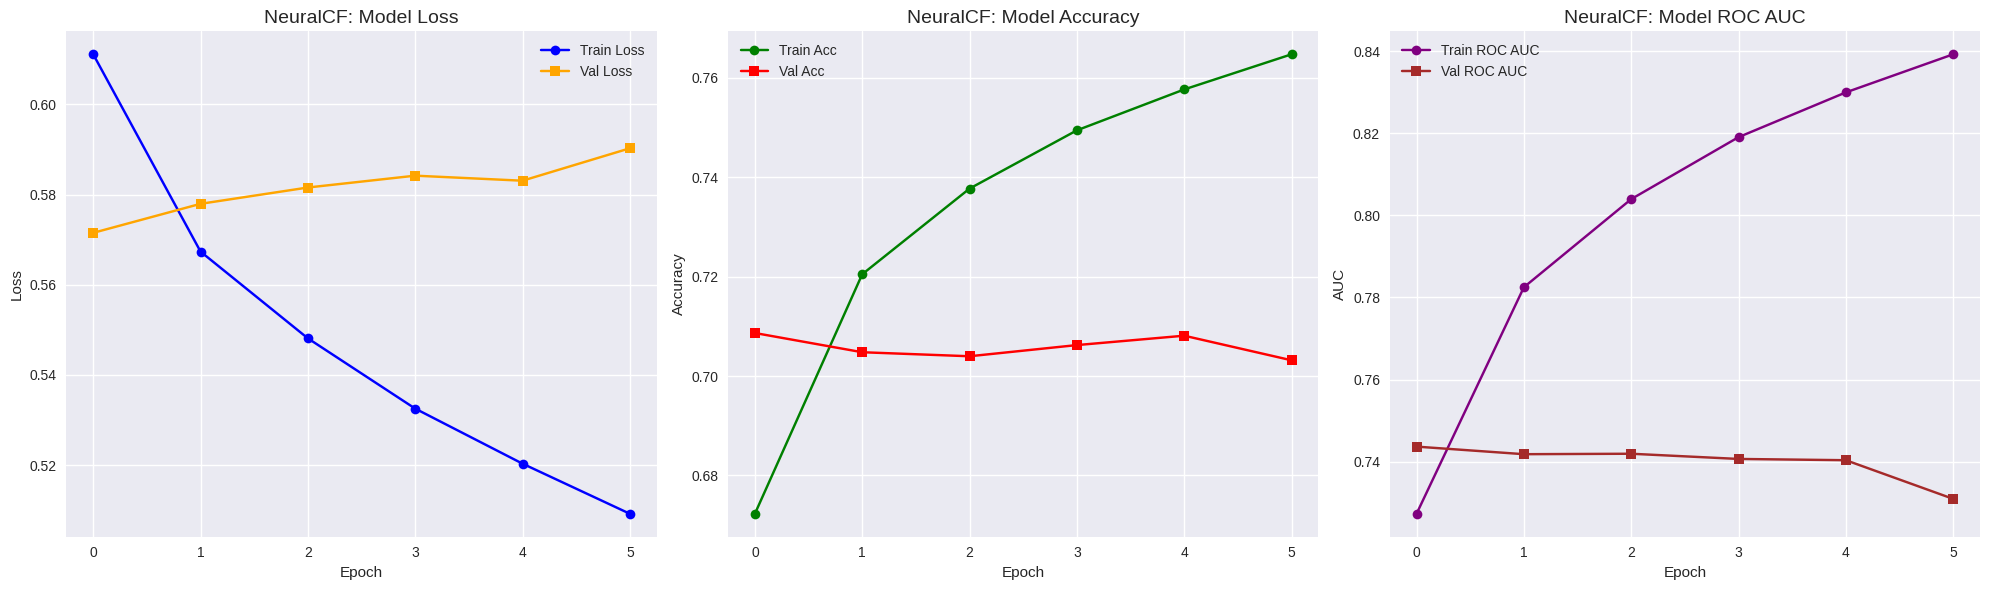

In [16]:
import matplotlib.pyplot as plt

# 设置绘图风格
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. 绘制 Loss 曲线
axes[0].plot(history.history['loss'], label='Train Loss', marker='o', color='b')
if 'val_loss' in history.history:
    axes[0].plot(history.history['val_loss'], label='Val Loss', marker='s', color='orange')
axes[0].set_title('NeuralCF: Model Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# 2. 绘制 Accuracy 曲线
axes[1].plot(history.history['accuracy'], label='Train Acc', marker='o', color='g')
if 'val_accuracy' in history.history:
    axes[1].plot(history.history['val_accuracy'], label='Val Acc', marker='s', color='red')
axes[1].set_title('NeuralCF: Model Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# 3. 绘制 ROC AUC 曲线
# 根据代码历史，指标名为 'roc_auc'
axes[2].plot(history.history['roc_auc'], label='Train ROC AUC', marker='o', color='purple')
if 'val_roc_auc' in history.history:
    axes[2].plot(history.history['val_roc_auc'], label='Val ROC AUC', marker='s', color='brown')
axes[2].set_title('NeuralCF: Model ROC AUC', fontsize=14)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()

plt.tight_layout()
plt.show()

### 1. 导出 NeuralCF 模型
我们将模型导出到 `/content/models/neuralcf/1`。

In [17]:
import os
import shutil

# 定义路径
ncf_export_path = "/content/models/neuralcf/1"

# 清理旧导出
if os.path.exists(ncf_export_path):
    shutil.rmtree(ncf_export_path)

# 导出模型
model.export(ncf_export_path)
print(f"NeuralCF 模型已导出至: {ncf_export_path}")

Saved artifact at '/content/models/neuralcf/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): Dict[['movieId', TensorSpec(shape=(None,), dtype=tf.int32, name='movieId')], ['userId', TensorSpec(shape=(None,), dtype=tf.int32, name='userId')]]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136969870016336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136969870011152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136969870014416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136969870011344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136969870015568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136969870013072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136969870015952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136969870010000: TensorSpec(shape=(), dtype=tf.resource, name=None)
NeuralCF 模型已导出至: /content/models/neuralcf/1


### 2. 重启 TF Serving 加载 NeuralCF 模型

In [18]:
import time

print("正在停止旧服务并启动 NeuralCF 服务...")
!pkill -f tensorflow_model_server

os.environ['NCF_MODEL_BASE_PATH'] = "/content/models/neuralcf"

# 启动服务，命名为 sparrow_ncf
!nohup tensorflow_model_server \
    --rest_api_port=8501 \
    --model_name=sparrow_ncf \
    --model_base_path=$NCF_MODEL_BASE_PATH \
    > server_ncf.log 2>&1 &

# 等待启动并检查日志
time.sleep(5)
!tail -n 5 server_ncf.log

正在停止旧服务并启动 NeuralCF 服务...
I0000 00:00:1782318259.236286   14169 server_core.cc:645]  (Re-)adding model: sparrow_ncf
I0000 00:00:1782318259.504851   14173 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1782318259.675736   14169 server_core.cc:537] Finished adding/updating models
[warn] getaddrinfo: address family for nodename not supported
[evhttp_server.cc : 261] NET_LOG: Entering the event loop ...


### 3. Python 端预测测试
从测试集中读取第一条数据进行验证。

In [23]:
import requests
import json
import pandas as pd

# 1. 读取一条测试数据
sample_df = pd.read_csv(test_path).iloc[0:1]

# --- 新增：打印读取到的数据 ---
print("--- 读取到的测试样本数据 ---")
print(sample_df.iloc[0].to_string())
print("-" * 30)

# 2. 构造输入数据 (NeuralCF)
# 根据模型签名修正：去掉外层列表，直接传入数值
instance = {
    "movieId": int(sample_df['movieId'].iloc[0]) % 1001,
    "userId": int(sample_df['userId'].iloc[0]) % 30001
}

# 3. 发送请求
predict_url = f"{public_url}/v1/models/sparrow_ncf:predict"
payload = json.dumps({"instances": [instance]})
headers = {"content-type": "application/json"}

response = requests.post(predict_url, data=payload, headers=headers)

if response.status_code == 200:
    res_json = response.json()
    score = res_json['predictions'][0][0]
    print(f"预测点击概率 (CTR): {score:.4%}")
    print(f"实际标签 (Label): {sample_df['label'].iloc[0]}")
else:
    print(f"预测失败: {response.status_code}")
    print(response.text)

--- 读取到的测试样本数据 ---
movieId                         223
userId                         9077
rating                          2.5
timestamp                1247908275
label                             0
releaseYear                    1994
movieGenre1                  Comedy
movieGenre2                     NaN
movieGenre3                     NaN
movieRatingCount               5102
movieAvgRating                 3.86
movieRatingStddev              0.97
userRatedMovie1                32.0
userRatedMovie2               735.0
userRatedMovie3               968.0
userRatedMovie4               750.0
userRatedMovie5               908.0
userRatingCount                  10
userAvgReleaseYear             1982
userReleaseYearStddev         15.33
userAvgRating                  3.85
userRatingStddev               0.53
userGenre1                 Thriller
userGenre2                   Action
userGenre3                   Sci-Fi
userGenre4                    Drama
userGenre5                   Horror
---------

### 4. 生成 Windows CMD `curl` 调用命令

In [24]:
import json

# 构造适合 NeuralCF 签名要求的 Payload (使用标量值而非数组)
instance_data = {
    "movieId": int(sample_df['movieId'].iloc[0]) % 1001,
    "userId": int(sample_df['userId'].iloc[0]) % 30001
}
payload = {"instances": [instance_data]}
json_payload = json.dumps(payload, separators=(',', ':'))

# 转义双引号供 Windows CMD 使用
escaped_json = json_payload.replace('"', '\\\"')

# 构建命令
cmd_command = f'curl -X POST "{public_url}/v1/models/sparrow_ncf:predict" -H "Content-Type: application/json" -d "{escaped_json}"'

print("请复制以下命令到 Windows CMD 执行:\n")
print(cmd_command)

请复制以下命令到 Windows CMD 执行:

curl -X POST "https://footbath-naming-impaired.ngrok-free.dev/v1/models/sparrow_ncf:predict" -H "Content-Type: application/json" -d "{\"instances\":[{\"movieId\":223,\"userId\":9077}]}"
